In [1]:
# Import Required Libraries

import warnings

warnings.filterwarnings("ignore")

import os

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
# Set Display Options

pd.set_option(

    "display.max_columns",

    None

)

pd.set_option(

    "display.float_format",

    "{:.3f}".format

)

In [3]:
# Load Model Evaluation Results

baseline_results = pd.read_csv(

    "../results/baseline_model_results.csv"

)

tuned_results = pd.read_csv(

    "../results/tuned_model_results.csv"

)

best_model_summary = pd.read_csv(

    "../results/best_model_summary.csv"

)

In [4]:
# Load Explainability Results

feature_importance = pd.read_csv(

    "../results/feature_importance.csv"

)

permutation_importance = pd.read_csv(

    "../results/permutation_importance.csv"

)

shap_importance = pd.read_csv(

    "../results/shap_importance.csv"

)

consensus_importance = pd.read_csv(

    "../results/consensus_feature_importance.csv"

)

In [5]:
# Load Sensor Optimization Results

sensor_results = pd.read_csv(

    "../results/sensor_purging_results.csv"

)

selected_features = pd.read_csv(

    "../results/selected_features.csv"

)

In [6]:
# Load Redundant Sensor Prediction Results

sensor_prediction_results = pd.read_csv(

    "../results/sensor_prediction_results.csv"

)

predicted_sensors = pd.read_csv(

    "../results/predicted_sensors.csv"

)

In [7]:
# Verify Loaded Results

print(

    "Baseline Models :",

    baseline_results.shape

)

print(

    "Tuned Models :",

    tuned_results.shape

)

print(

    "Feature Importance :",

    feature_importance.shape

)

print(

    "Consensus Ranking :",

    consensus_importance.shape

)

print(

    "Sensor Purging Results :",

    sensor_results.shape

)

print(

    "Selected Sensors :",

    selected_features.shape

)

print(

    "Sensor Prediction Results :",

    sensor_prediction_results.shape

)

print(

    "Predicted Sensors :",

    predicted_sensors.shape

)

Baseline Models : (11, 6)
Tuned Models : (3, 6)
Feature Importance : (29, 2)
Consensus Ranking : (29, 5)
Sensor Purging Results : (6, 5)
Selected Sensors : (10, 1)
Sensor Prediction Results : (11, 4)
Predicted Sensors : (11, 1)


In [8]:
# Summarize Best Prediction Model

display(

    best_model_summary

)

best_model = best_model_summary.loc[

    0,

    "Model"

]

best_rmse = best_model_summary.loc[

    0,

    "RMSE"

]

best_r2 = best_model_summary.loc[

    0,

    "R²"

]

print(

    "Best Model :",

    best_model

)

print(

    "RMSE :",

    round(best_rmse, 3)

)

print(

    "R² Score :",

    round(best_r2, 3)

)

,Model,MAE,RMSE,R²,Adjusted R²
0,CatBoost,0.526,0.826,0.999,0.999


Best Model : CatBoost
RMSE : 0.826
R² Score : 0.999


In [9]:
# Compare Best Version of Each Model

comparison = pd.concat(

    [

        baseline_results,

        tuned_results

    ],

    ignore_index=True

)

comparison = comparison.sort_values(

    by="RMSE"

)

comparison = comparison.drop_duplicates(

    subset="Model",

    keep="first"

).reset_index(

    drop=True

)

display(

    comparison

)

,Model,Version,MAE,RMSE,R²,Adjusted R²
0,CatBoost,Baseline,0.526,0.826,0.999,0.999
1,Extra Trees,Baseline,0.464,1.023,0.998,0.998
2,Random Forest,Baseline,0.623,1.334,0.997,0.997
3,LightGBM,Tuned,0.734,1.383,0.997,0.997
4,XGBoost,Tuned,0.959,1.558,0.996,0.996
5,Decision Tree,Baseline,1.301,2.548,0.990,0.990
6,Gradient Boosting,Baseline,1.908,3.104,0.985,0.985
7,Ridge,Baseline,4.623,6.399,0.936,0.936
8,Linear Regression,Baseline,4.623,6.400,0.936,0.936
9,Lasso,Baseline,6.407,8.931,0.875,0.875


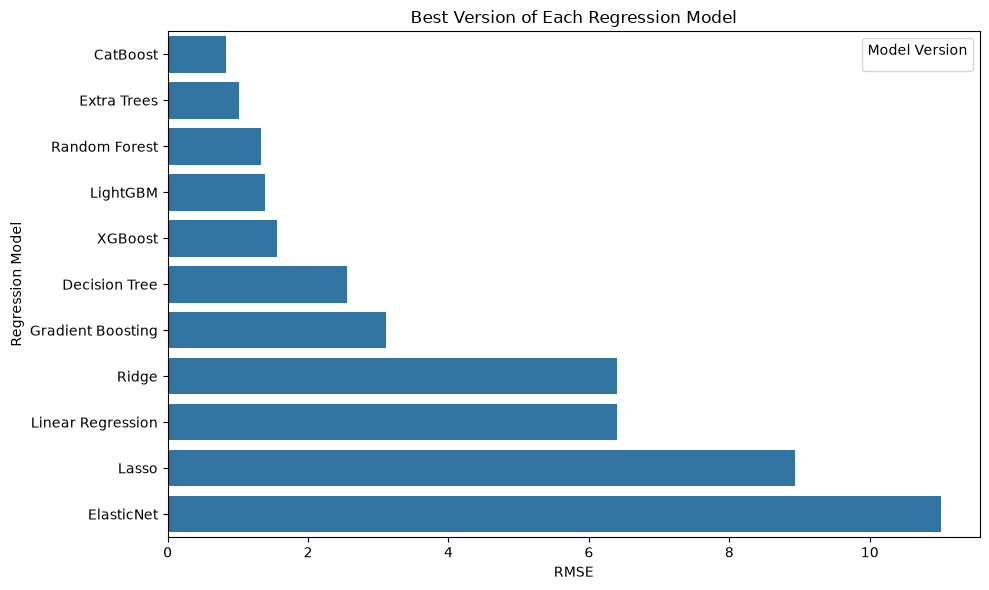

In [10]:
plt.figure(

    figsize=(10, 6)

)

sns.barplot(

    data=comparison,

    x="RMSE",

    y="Model"

)

plt.title(

    "Best Version of Each Regression Model"

)

plt.xlabel(

    "RMSE"

)

plt.ylabel(

    "Regression Model"

)

plt.legend(

    title="Model Version"

)

plt.tight_layout()

plt.show()

In [11]:
# Display Best Performing Models

display(

    comparison.head(5)

)

,Model,Version,MAE,RMSE,R²,Adjusted R²
0,CatBoost,Baseline,0.526,0.826,0.999,0.999
1,Extra Trees,Baseline,0.464,1.023,0.998,0.998
2,Random Forest,Baseline,0.623,1.334,0.997,0.997
3,LightGBM,Tuned,0.734,1.383,0.997,0.997
4,XGBoost,Tuned,0.959,1.558,0.996,0.996


In [12]:
# Display Consensus Feature Importance

display(

    consensus_importance.head(10)

)

,Feature,CatBoost,Permutation,SHAP,Consensus
0,Eta_Difference,1.000,1.000,1.000,1.000
1,Total_PT,0.997,0.934,0.720,0.884
2,Cos_Theta,0.361,0.734,0.765,0.620
3,Total_Energy,0.242,0.708,0.652,0.534
4,E1,0.183,0.320,0.359,0.287
5,Phi_Difference,0.126,0.234,0.272,0.210
6,Momentum2,0.125,0.236,0.264,0.208
7,pt1,0.076,0.239,0.252,0.189
8,pt2,0.057,0.236,0.219,0.171
9,Momentum1,0.079,0.171,0.178,0.143


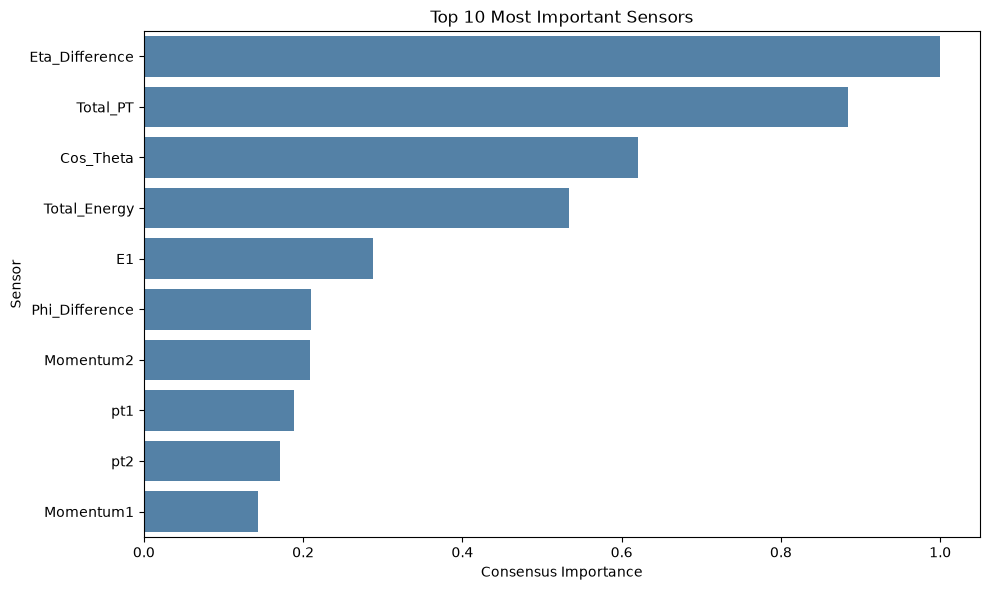

In [13]:
# Visualize Top Important Sensors

plt.figure(

    figsize=(10, 6)

)

sns.barplot(

    data=consensus_importance.head(10),

    x="Consensus",

    y="Feature",

    color="steelblue"

)

plt.title(

    "Top 10 Most Important Sensors"

)

plt.xlabel(

    "Consensus Importance"

)

plt.ylabel(

    "Sensor"

)

plt.tight_layout()

plt.show()

In [14]:
# Display Selected Sensors

display(

    selected_features

)

print(

    "Number of Selected Sensors :",

    len(selected_features)

)

,Feature
0,Eta_Difference
1,Total_PT
2,Cos_Theta
3,Total_Energy
4,E1
5,Phi_Difference
6,Momentum2
7,pt1
8,pt2
9,Momentum1


Number of Selected Sensors : 10


In [15]:
# Display Sensor Purging Results

display(

    sensor_results

)

,Sensors,MAE,RMSE,R²,RMSE Increase (%)
0,29,0.516,0.833,0.999,0.000
1,15,0.519,0.818,0.999,-1.857
2,12,0.516,0.814,0.999,-2.297
3,10,0.511,0.815,0.999,-2.136
4,8,0.554,0.873,0.999,4.829
5,5,1.104,2.174,0.993,160.942


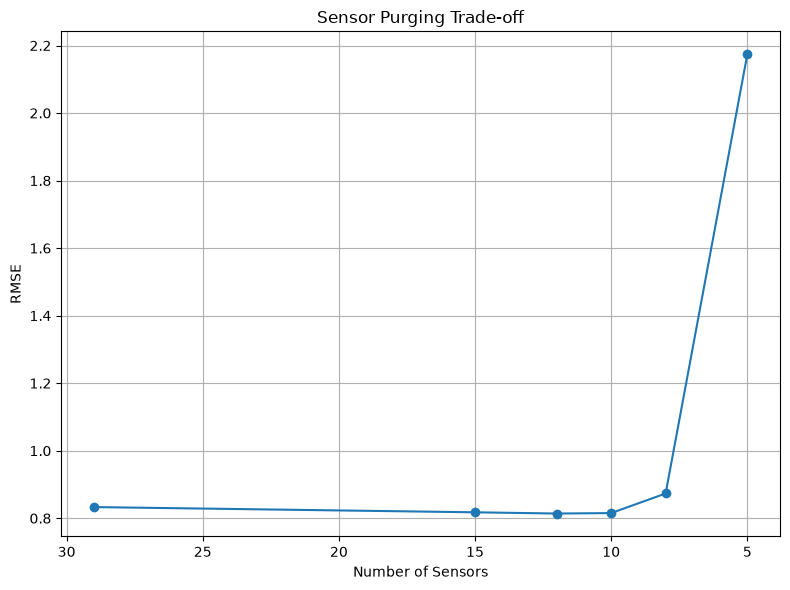

In [16]:
# Visualize Sensor Trade-off

plt.figure(

    figsize=(8, 6)

)

plt.plot(

    sensor_results["Sensors"],

    sensor_results["RMSE"],

    marker="o"

)

plt.gca().invert_xaxis()

plt.title(

    "Sensor Purging Trade-off"

)

plt.xlabel(

    "Number of Sensors"

)

plt.ylabel(

    "RMSE"

)

plt.grid(True)

plt.tight_layout()

plt.show()

In [17]:
# Summarize Sensor Optimization

full_sensor_result = sensor_results.loc[

    sensor_results["Sensors"].idxmax()

]

print(

    "RMSE Using All Sensors :",

    round(

        full_sensor_result["RMSE"],

        3

    )

)

print(

    "Recommended Sensor Count :",

    len(selected_features)

)

print()

print(

    "Recommended Sensors"

)

display(

    selected_features

)

RMSE Using All Sensors : 0.833
Recommended Sensor Count : 10

Recommended Sensors


,Feature
0,Eta_Difference
1,Total_PT
2,Cos_Theta
3,Total_Energy
4,E1
5,Phi_Difference
6,Momentum2
7,pt1
8,pt2
9,Momentum1


In [18]:
# Display Redundant Sensor Prediction Results

display(

    sensor_prediction_results

)

,Sensor,MAE,RMSE,R²
0,E2,18.049,27.526,0.650
1,eta1,1.254,1.468,-0.004
2,phi2,1.567,1.812,-0.005
3,phi1,1.559,1.805,-0.007
4,eta2,1.584,1.748,-0.009
5,py1,9.231,13.669,-0.025
6,py2,8.845,13.344,-0.031
7,px1,9.223,13.796,-0.041
8,px2,8.842,13.297,-0.051
9,pz2,40.837,62.995,-0.051


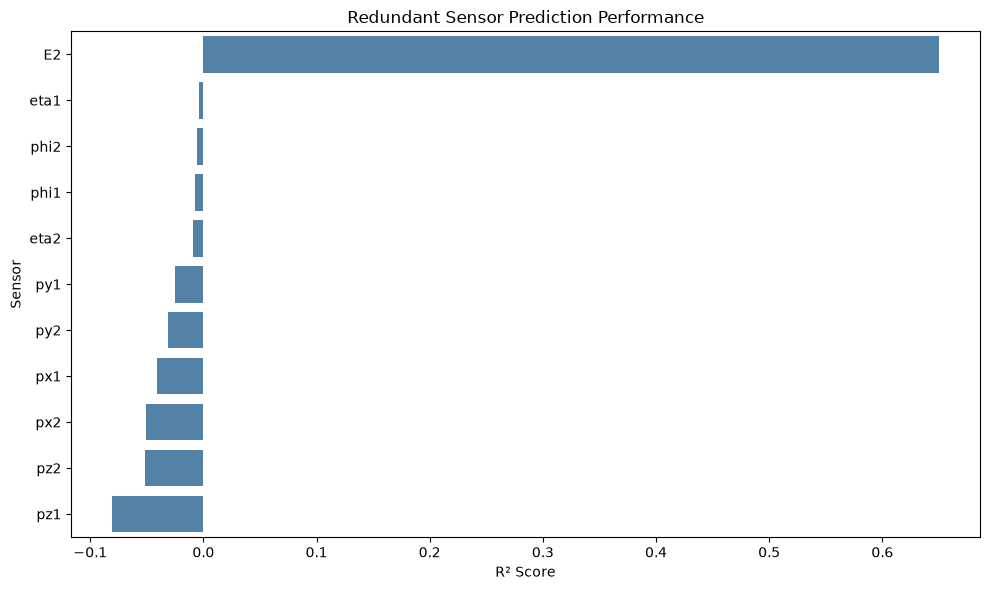

In [19]:
# Visualize Redundant Sensor Prediction Performance

plt.figure(

    figsize=(10, 6)

)

sns.barplot(

    data=sensor_prediction_results,

    x="R²",

    y="Sensor",

    color="steelblue"

)

plt.title(

    "Redundant Sensor Prediction Performance"

)

plt.xlabel(

    "R² Score"

)

plt.ylabel(

    "Sensor"

)

plt.tight_layout()

plt.show()

In [20]:
# Display Predicted Sensors

display(

    predicted_sensors
)

print(

    "Number of Predicted Sensors :",

    len(predicted_sensors)

)

,Sensor
0,px1
1,py1
2,pz1
3,eta1
4,phi1
5,E2
6,px2
7,py2
8,pz2
9,eta2


Number of Predicted Sensors : 11


In [21]:
# Summarize Redundant Sensor Prediction

best_prediction = sensor_prediction_results.loc[

    sensor_prediction_results["R²"].idxmax()

]

print(

    "Best Reconstructed Sensor :",

    best_prediction["Sensor"]

)

print(

    "R² Score :",

    round(

        best_prediction["R²"],

        3

    )

)

print(

    "RMSE :",

    round(

        best_prediction["RMSE"],

        3

    )

)

Best Reconstructed Sensor : E2
R² Score : 0.65
RMSE : 27.526


In [23]:
# Display Final Project Summary

summary = pd.DataFrame({

    "Metric": [

        "Best Prediction Model",

        "Best RMSE",

        "Best R² Score",

        "Recommended Sensors",

        "Predicted Redundant Sensors",

        "Best Reconstructed Sensor"

    ],

    "Value": [

        best_model,

        round(best_rmse, 3),

        round(best_r2, 3),

        len(selected_features),

        len(predicted_sensors),

        best_prediction["Sensor"]

    ]

})

display(summary)

,Metric,Value
0,Best Prediction Model,CatBoost
1,Best RMSE,0.826
2,Best R² Score,0.999
3,Recommended Sensors,10
4,Predicted Redundant Sensors,11
5,Best Reconstructed Sensor,E2


In [24]:
# Save Final Project Summary

os.makedirs(

    "../results",

    exist_ok=True

)

summary.to_csv(

    "../results/final_project_summary.csv",

    index=False

)

print(

    "Final Project Summary Saved Successfully"

)

Final Project Summary Saved Successfully
